# Coursera - IBM ML - Deep Learning and Reinforcement Learning Final Project


#### Resources:
- [Kaggle Quick Draw Getting Started](https://www.kaggle.com/code/aleksandradeis/getting-started-with-pytorch-for-quick-draw)
- [Kaggle Quick Draw Competition](https://www.kaggle.com/competitions/quickdraw-doodle-recognition/data)
- [Modern VAE in PyTorch](https://hunterheidenreich.com/posts/modern-variational-autoencoder-in-pytorch/)
- [PyTorch Docs - Adam](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)
- [PyTorch Docs - Datasets and Dataloaders](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)

In [1]:
import os
from pathlib import Path
import numpy as np

In [2]:
DATA_PATH = Path(r"C:\datasets\google-quickdraw\sketches")
classes = [line.stem for line in DATA_PATH.glob("**/*.npz")]
files = [line for line in DATA_PATH.glob("**/*.npz")]

Let's first investigate some of the images. We'll do this with a representative sample of the airplane images.

In [3]:
AIRPLANE_FILE = 'C:/datasets/google-quickdraw/sketches/airplane.npz'

with np.load(AIRPLANE_FILE, encoding='latin1', allow_pickle=True) as airplane_f:
    test = airplane_f["test"]
    train = airplane_f["train"]
    valid = airplane_f["valid"]

c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


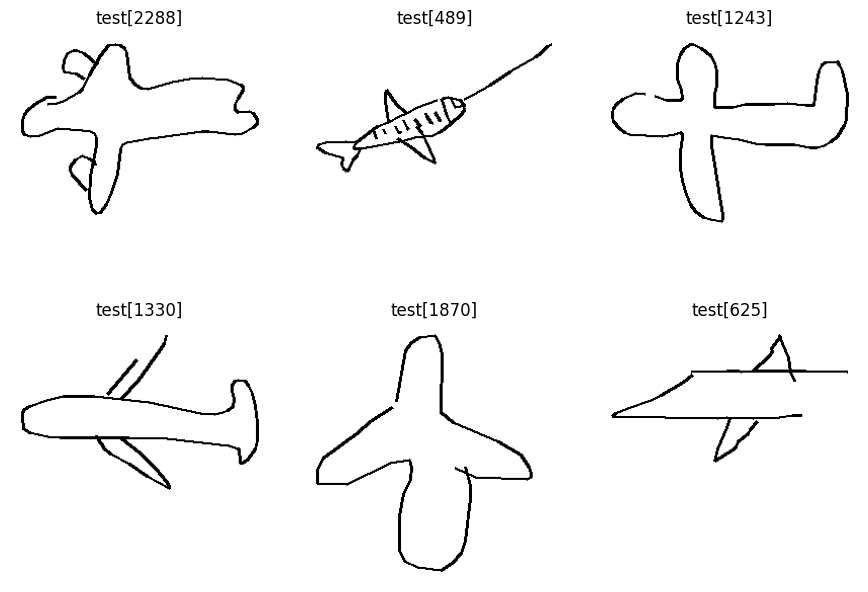

In [4]:
from PIL import Image, ImageDraw

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
indices = np.random.choice(len(test), size=6, replace=False)

for ax, idx in zip(axes.ravel(), indices):
    image = test[idx]
    xy = np.cumsum(image[:, :2], axis=0).astype(np.float32)
    pen_up = image[:, 2].astype(bool)

    # Normalize points to a fixed PIL canvas
    canvas_size, pad = 256, 12
    x_min, y_min = xy.min(axis=0)
    x_max, y_max = xy.max(axis=0)
    span = max(x_max - x_min, y_max - y_min, 1.0)
    scale = (canvas_size - 2 * pad) / span

    pts = np.empty_like(xy)
    pts[:, 0] = (xy[:, 0] - x_min) * scale + pad
    pts[:, 1] = (xy[:, 1] - y_min) * scale + pad

    pil_img = Image.new("L", (canvas_size, canvas_size), 255)  # white bg
    draw = ImageDraw.Draw(pil_img)

    start = 0
    for end in np.where(pen_up)[0]:
        seg = pts[start:end + 1]
        if len(seg) > 1:
            draw.line([tuple(p) for p in seg], fill=0, width=3)
        start = end + 1

    if start < len(pts) - 1:
        seg = pts[start:]
        if len(seg) > 1:
            draw.line([tuple(p) for p in seg], fill=0, width=3)

    ax.imshow(np.array(pil_img), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"test[{idx}]")
    ax.axis("off")

plt.tight_layout()
plt.show()

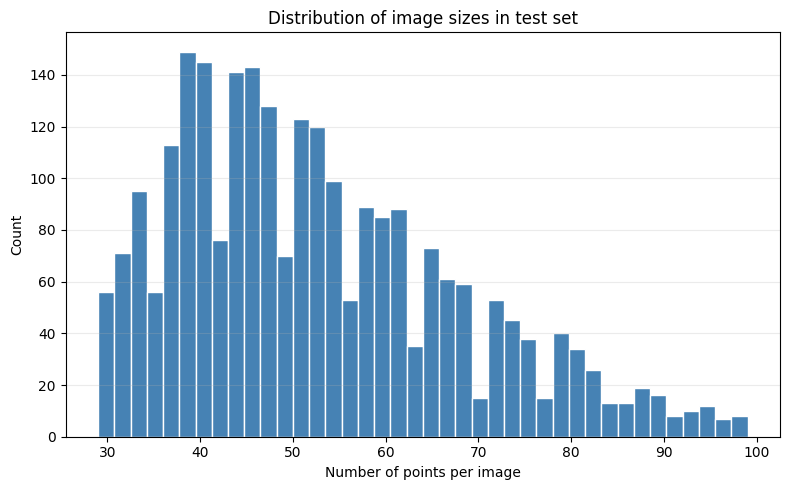

In [5]:
# "Image size" here is measured as the number of points (rows) in each test sketch
test_sizes = np.array([stroke.shape[0] for stroke in test], dtype=np.int32)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(test_sizes, bins=40, color="steelblue", edgecolor="white")
ax.set_title("Distribution of image sizes in test set")
ax.set_xlabel("Number of points per image")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, Sampler

class CachedQuickDrawDataset(Dataset):
    def __init__(self, labels, data_path, split="train", counts: dict[str, int] = None, max_length=None, cache_dir=None):
        self.labels = labels
        self.data_path = Path(data_path)
        self.split = split
        self.max_length = max_length
        self.label_files = [self.data_path / f"{label}.npz" for label in labels]
        
        # Create cache directory for rendered images
        if cache_dir is None:
            cache_dir = Path(data_path) / f"cache_{split}"
        self.cache_dir = Path(cache_dir)
        # Defer directory creation until first use to avoid multiprocessing race conditions
        self._cache_dir_created = False

        if counts is None:
            # number of samples per label for this split
            self.counts = {}
            for fpath, label in zip(self.label_files, labels):
                with np.load(fpath, encoding="latin1", allow_pickle=True) as f:
                    self.counts[label] = len(f[split])
        else:
            self.counts = counts

    def _get_cache_path(self, label_idx, sample_idx):
        return self.cache_dir / f"label_{label_idx}_sample_{sample_idx}.npy"

    def _render_image(self, stroke):
        """Render stroke data to image array"""
        if self.max_length is not None:
            stroke = stroke[:self.max_length]

        xy = np.cumsum(stroke[:, :2], axis=0).astype(np.float32)
        pen_up = stroke[:, 2].astype(bool)

        canvas_size, pad = 128, 12
        x_min, y_min = xy.min(axis=0)
        x_max, y_max = xy.max(axis=0)
        span = max(x_max - x_min, y_max - y_min, 1.0)
        scale = (canvas_size - 2 * pad) / span

        pts = np.empty_like(xy)
        pts[:, 0] = (xy[:, 0] - x_min) * scale + pad
        pts[:, 1] = (xy[:, 1] - y_min) * scale + pad

        pil_img = Image.new("L", (canvas_size, canvas_size), 255)
        draw = ImageDraw.Draw(pil_img)

        start = 0
        for end in np.where(pen_up)[0]:
            seg = pts[start:end + 1]
            if len(seg) > 1:
                draw.line([tuple(p) for p in seg], fill=0, width=3)
            start = end + 1

        if start < len(pts) - 1:
            seg = pts[start:]
            if len(seg) > 1:
                draw.line([tuple(p) for p in seg], fill=0, width=3)

        return np.array(pil_img, dtype=np.float32) / 255.0

    def __len__(self):
        return sum(v for v in self.counts.values())

    def __getitem__(self, index):
        # index is expected as (label_idx, sample_idx) from custom batch sampler
        label_idx, sample_idx = index
        
        # Ensure cache directory exists (safe for multiprocessing)
        if not self._cache_dir_created:
            try:
                self.cache_dir.mkdir(parents=True, exist_ok=True)
                self._cache_dir_created = True
            except Exception:
                pass  # Dir may already exist from another process
        
        cache_path = self._get_cache_path(label_idx, sample_idx)

        # Try to load from cache first
        if cache_path.exists():
            img_array = np.load(cache_path)
        else:
            # Load from npz and render
            with np.load(self.label_files[label_idx], encoding="latin1", allow_pickle=True) as f:
                stroke = f[self.split][sample_idx]
            
            img_array = self._render_image(stroke)
            
            # Save to cache for future use (handle file conflicts in multiprocessing)
            try:
                np.save(cache_path, img_array)
            except Exception as e:
                print(e)
                pass  # File may have been saved by another worker

        return torch.from_numpy(img_array).unsqueeze(0), label_idx


class DifferentLabelBatchSampler(Sampler):
    def __init__(self, label_counts, batch_size, steps_per_epoch, seed=42):
        self.label_counts = label_counts
        self.counts_list = list(label_counts.values())
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.valid_labels = [i for i, c in enumerate(label_counts.values()) if c > 0]

        if batch_size > len(self.valid_labels):
            raise ValueError(f"batch_size={batch_size} > number of available labels={len(self.valid_labels)}")

        self.g = torch.Generator()
        self.g.manual_seed(seed)

    def __len__(self):
        return self.steps_per_epoch

    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            label_perm = torch.randperm(len(self.valid_labels), generator=self.g)[:self.batch_size]
            chosen_labels = [self.valid_labels[i] for i in label_perm.tolist()]

            batch = []
            for label_idx in chosen_labels:
                sample_idx = int(torch.randint(self.counts_list[label_idx], (1,), generator=self.g).item())
                batch.append((label_idx, sample_idx))

            yield batch


def collate_fn(batch):
    images, labels = zip(*batch)
    return torch.stack(images, dim=0), torch.tensor(labels, dtype=torch.long)


# Reproducible settings
seed = 123
batch_size = 32

train_dataset = CachedQuickDrawDataset(classes, DATA_PATH, split="train", counts={k:70000 for k in classes})
valid_dataset = CachedQuickDrawDataset(classes, DATA_PATH, split="valid", counts={k:2500 for k in classes})
test_dataset = CachedQuickDrawDataset(classes, DATA_PATH, split="test", counts={k:2500 for k in classes})

train_steps = len(train_dataset) // batch_size
valid_steps = len(valid_dataset) // batch_size
test_steps = len(test_dataset) // batch_size

train_sampler = DifferentLabelBatchSampler(train_dataset.counts, batch_size, train_steps, seed=seed)
valid_sampler = DifferentLabelBatchSampler(valid_dataset.counts, batch_size, valid_steps, seed=seed + 1)
test_sampler = DifferentLabelBatchSampler(test_dataset.counts, batch_size, test_steps, seed=seed + 2)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_sampler=valid_sampler, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, collate_fn=collate_fn)

With the dataloader we can now grab a sample batch and see what it looks like. The first time it is run it will take a while, but since the dataloader caches the images subsequent runs will be faster.

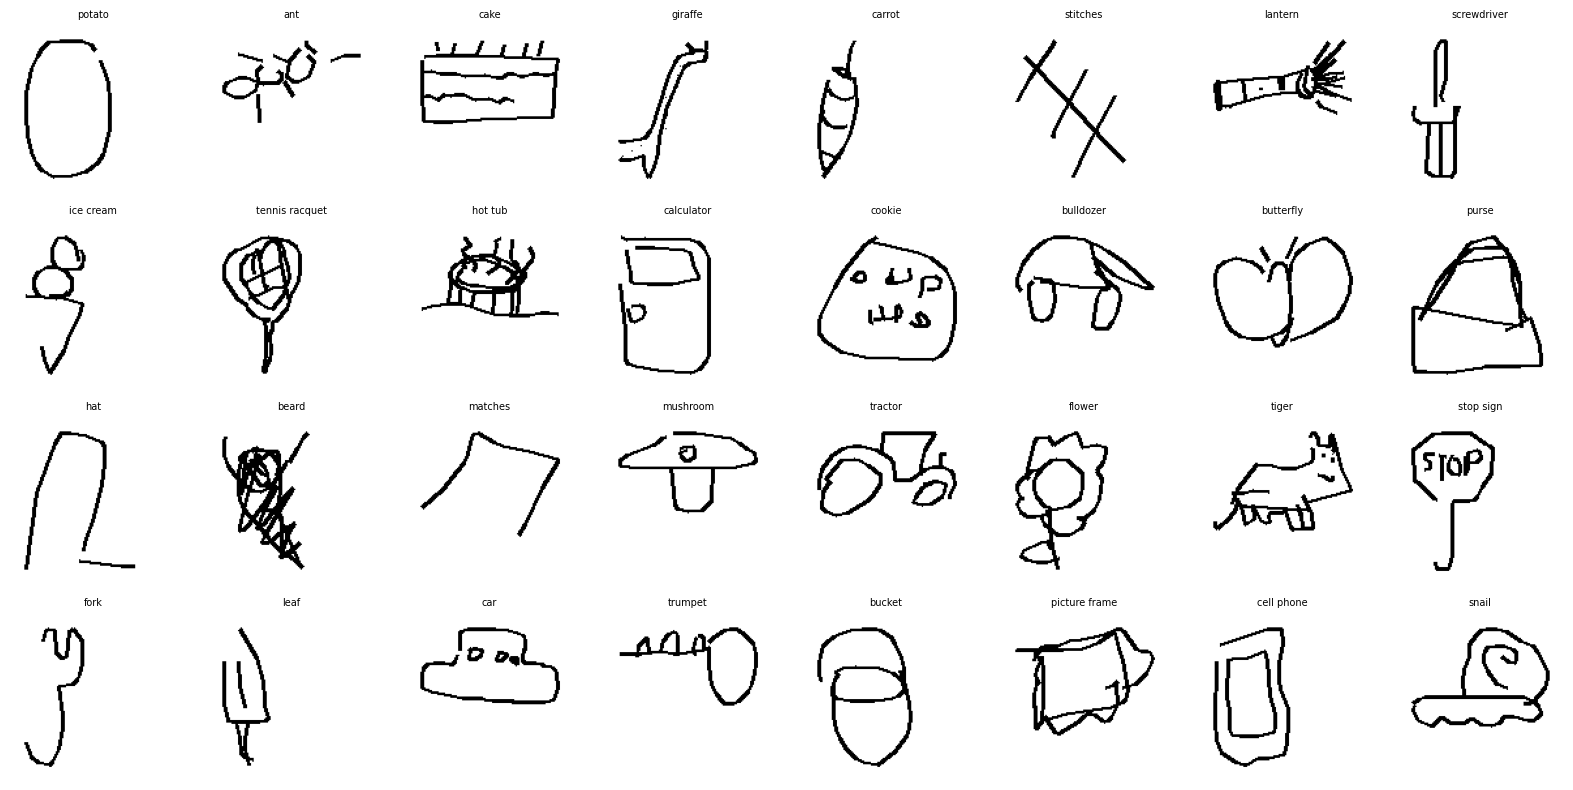

In [12]:
images, labels = next(iter(train_loader)) # [32, 1, 128, 128], [32]

fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for ax, img, label in zip(axes.ravel(), images, labels):
    ax.imshow(img.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(classes[label.item()], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

## The Model

For the model I'll use a Variational Auto Encoder. This way the classifier will also be usable as a generative model, where we can use it to generate new doodles.

The first model we'll use as a baseline is from [hunterheidenrech](https://hunterheidenreich.com/posts/modern-variational-autoencoder-in-pytorch/). This model simply takes the source image as a vector and then does its VAE magic.

In [13]:
import os
# Disable torch.compile and dynamo to avoid version compatibility issues
os.environ["TORCH_COMPILE_DEBUG"] = "0"
os.environ["TORCH_DISABLE_DYNAMIC_COMPILE"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

# Additional safety: disable dynamo if it exists
try:
    torch._dynamo.config.suppress_errors = True
except:
    pass

@dataclass
class VAEOutput:
    z: torch.Tensor
    mu: torch.Tensor
    std: torch.Tensor
    x_recon: torch.Tensor
    loss: torch.Tensor
    loss_recon: torch.Tensor
    loss_kl: torch.Tensor

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_std = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        # Softplus + epsilon for stable std deviation
        std = F.softplus(self.fc_std(h)) + 1e-6
        return mu, std

    def reparameterize(self, mu, std):
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, kl_weight=1.0):
        mu, std = self.encode(x)
        z = self.reparameterize(mu, std)
        x_recon = self.decode(z)

        # 1. Reconstruction Loss (Binary Cross Entropy for MNIST)
        # Sum over features, mean over batch
        recon_loss = F.binary_cross_entropy_with_logits(x_recon, x, reduction='none').sum(dim=1).mean()

        # 2. KL Divergence
        # Analytic KL for Normal distributions
        kl_loss = -0.5 * torch.sum(1 + torch.log(std**2) - mu**2 - std**2, dim=1).mean()

        # 3. Total Loss (ELBO)
        loss = recon_loss + (kl_weight * kl_loss)

        return VAEOutput(z, mu, std, x_recon, loss, recon_loss, kl_loss)

# --- Training Loop Example ---
def train_step(model, batch, optimizer, kl_weight=1.0):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    output = model(batch, kl_weight)

    # Backward pass
    output.loss.backward()

    # Gradient clipping (recommended)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    return output.loss.item()

In [14]:
vae_v1 = VAE(input_dim=128*128)

In [15]:
EPOCHS = 5
optimizer = torch.optim.Adam(vae_v1.parameters(), lr=1e-3)

for epoch in range(EPOCHS):
    train_loss = 0.0
    
    for batch_images, _ in train_loader:
        batch_flat = batch_images.reshape(batch_images.size(0), 128 * 128).float()
        loss = train_step(vae_v1, batch_flat, optimizer)
        train_loss += loss
    
    avg_train_loss = train_loss / train_steps
    
    # Validation
    vae_v1.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for batch_images, _ in valid_loader:
            batch_flat = batch_images.view(batch_images.size(0), -1).float()
            output = vae_v1(batch_flat)
            valid_loss += output.loss.item()
    
    avg_valid_loss = valid_loss / valid_steps
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f}")

KeyboardInterrupt: 